In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (ensure comment='#' is used)
df = pd.read_csv("../data/cumulative_koi.csv", comment='#')

# 1. Define Target (1 for Planet-like, 0 for False Positive)
df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'CANDIDATE': 1, 'FALSE POSITIVE': 0})

# 2. Define the 'Gold Mine' Columns
gold_mine = [
    'koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 
    'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 
    'koi_smass', 'koi_impact', 'koi_sma', 'koi_srho', 'koi_count', 'target'
]

# 3. Create the focused dataframe
df_eda = df[gold_mine].copy()

print(f"Data cleaned! We are now working with {df_eda.shape[1]} core features.")
display(df_eda.head())

Data cleaned! We are now working with 16 core features.


/tmp/ipykernel_201883/2662366379.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'CANDIDATE': 1, 'FALSE POSITIVE': 0})


,koi_period,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_smass,koi_impact,koi_sma,koi_srho,koi_count,target
0,9.488036,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,0.919,0.146,0.0853,3.20796,2,1
1,54.418383,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,0.919,0.586,0.2734,3.02368,2,1
2,19.899140,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,0.961,0.969,0.1419,7.29555,1,1
3,1.736952,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,0.836,1.276,0.0267,0.22080,1,0
4,2.525592,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,1.095,0.701,0.0374,1.98635,1,1


In [33]:
# Summary statistics for the 'Gold Mine' features
# We transpose (.T) to make it easier to read the 15 columns
summary = df_eda.describe().T
display(summary[['mean', 'std', 'min', '50%', 'max']])

,mean,std,min,50%,max
koi_period,75.671358,1334.744046,0.241843,9.752831,1.299958e+05
koi_duration,5.621606,6.471554,0.052000,3.792600,1.385400e+02
koi_depth,23791.343984,82242.684708,0.000000,421.100000,1.541400e+06
koi_prad,102.891778,3077.639126,0.080000,2.390000,2.003460e+05
koi_teq,1085.385828,856.351161,25.000000,878.000000,1.466700e+04
koi_insol,7745.737023,159204.665200,0.000000,141.600000,1.094755e+07
koi_model_snr,259.895001,795.806615,0.000000,23.000000,9.054700e+03
koi_steff,5706.823280,796.857947,2661.000000,5767.000000,1.589600e+04
koi_slogg,4.310157,0.432606,0.047000,4.438000,5.364000e+00
koi_srad,1.728712,6.127185,0.109000,1.000000,2.299080e+02


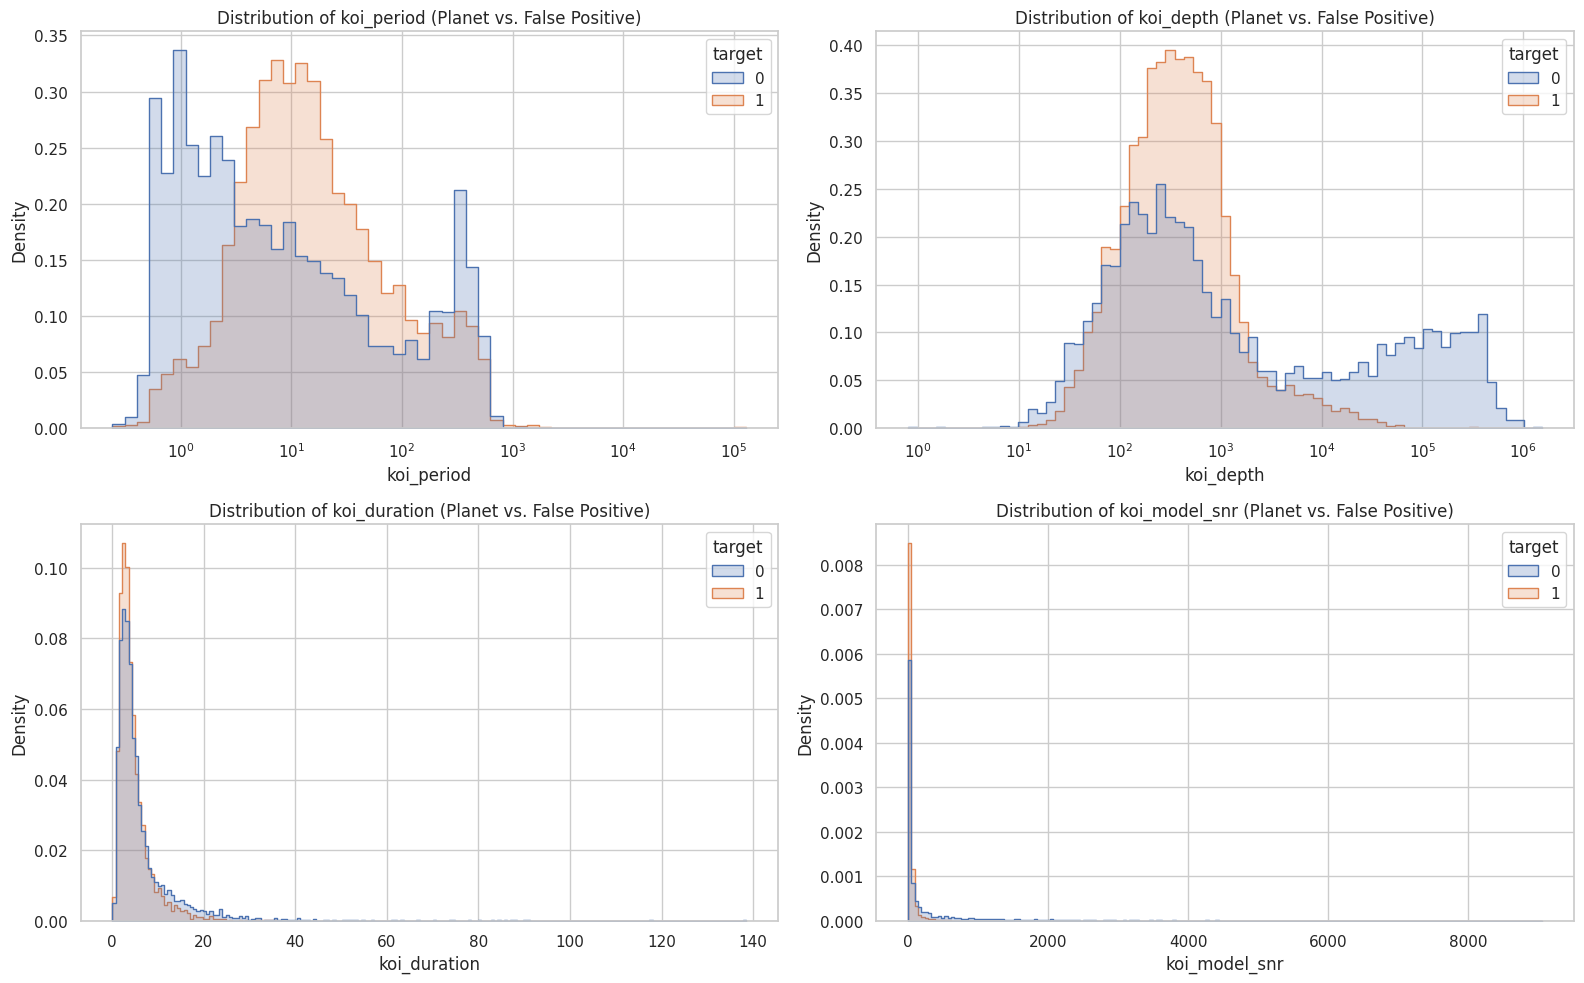

In [34]:
# Plotting the core transit features
transit_features = ['koi_period', 'koi_depth', 'koi_duration', 'koi_model_snr']

plt.figure(figsize=(16, 10))
for i, col in enumerate(transit_features):
    plt.subplot(2, 2, i+1)
    # Filter out NaN and infinite values
    data_clean = df_eda[[col, 'target']].dropna()
    data_clean = data_clean[~np.isinf(data_clean[col])]
    
    # Plot histogram without KDE (avoids numerical issues with edge cases)
    sns.histplot(data=data_clean, x=col, hue='target', element="step", stat="density",
                 log_scale=(col in ['koi_period', 'koi_depth']))
    plt.title(f'Distribution of {col} (Planet vs. False Positive)')

plt.tight_layout()
plt.show()

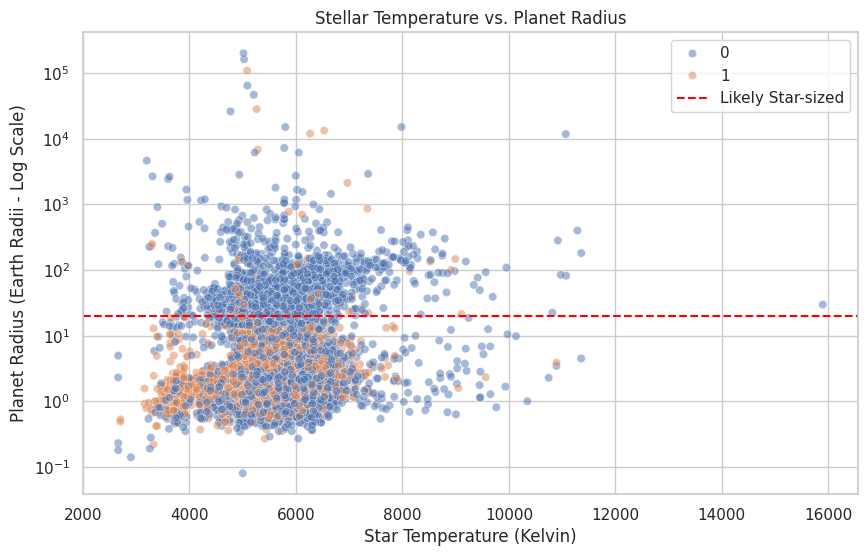

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='koi_steff', y='koi_prad', hue='target', alpha=0.5)
plt.yscale('log') # Radius varies wildly
plt.title('Stellar Temperature vs. Planet Radius')
plt.xlabel('Star Temperature (Kelvin)')
plt.ylabel('Planet Radius (Earth Radii - Log Scale)')
plt.axhline(20, color='red', linestyle='--', label='Likely Star-sized') # Reference line
plt.legend()
plt.show()

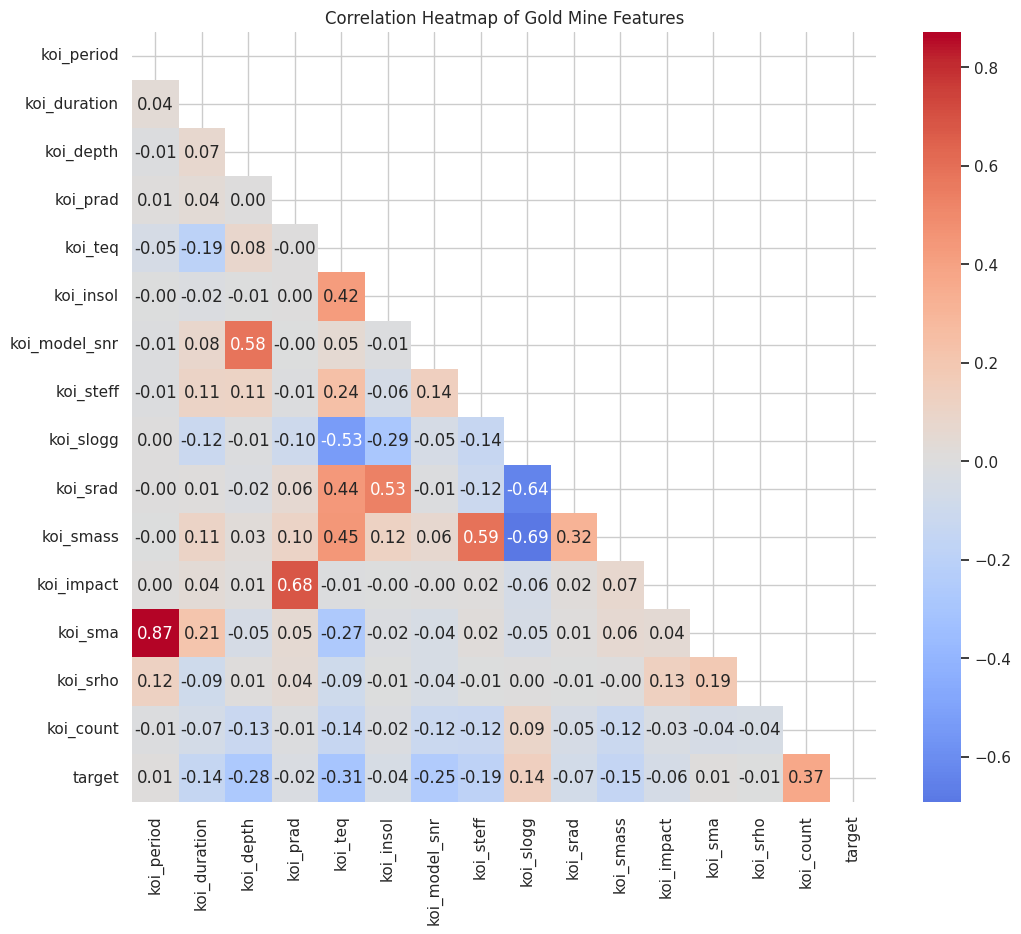

In [36]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df_eda.corr(), dtype=bool)) # Only show the bottom half
sns.heatmap(df_eda.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Gold Mine Features')
plt.show()